## Reading the Feature selection file data

In [3]:
# Function to read the input file
import pandas as pd

# Note: Please change the path here for the input file you want to read.
# Read column names from the .names file
df_names = pd.read_csv('./dataset/question_2/sonar/sonar.names', sep= ':', skiprows=1, header=None)
feature_list = df_names[0].tolist()

# Note: Please change the path here for the input file you want to read.
column_list = feature_list + ['class_label']
# Read data from the .data file
df_data = pd.read_csv('./dataset/question_2/sonar/sonar.data', names=column_list, index_col=False)

In [4]:
# Now, we have read the data file successfully and assign header too after reading the name file
df_data.head(5)

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,...,feature52,feature53,feature54,feature55,feature56,feature57,feature58,feature59,feature60,class_label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,1
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,1
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,1


## Importing the Required packages

In [5]:
import random
import math
import numpy as np
import time
from deap import base, creator, tools
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [6]:
# Mantaining the size of individual chromosome to be equal to the number of features present in the dataset
IND_SIZE = len(feature_list)
# Defining the Population size for the Genetic Algorithm
POPULATION_SIZE = 30
# Defining the number of generations for the Genetic Algorithm
NUM_OF_GENERATION = 50
# Defining the mutation rate for the child to be mutated
MUTATION_RATE = 0.20
# Calculating the elite size based on the population size, ensuring it is at least 2
ELITE_SIZE = max(2, int(0.05*POPULATION_SIZE))

### Helper functions

In [7]:
# Function to perform mutation on a child individual
def mutate_child(child):
    if random.random() < MUTATION_RATE:
        # Perform flip mutation on the child
        index = random.randrange(len(child))
        child[index] = 1 - child[index]
    return child

# Function to get selected feature list from individual chromosome list
def get_selected_features(individual):
     # List to store selected_feature list
    selected_features = list()

    # 1. Iterating over the individual chromosome to found the feature selected or not
    for index, item in enumerate(individual):
        # This mean this feature is selected
        if item == 1:
            selected_features.append(feature_list[index])

    return selected_features

# Classifier for Checking Accuracy of the Best Individual
def classify_selected_features(df, selected_features):
    # Extract selected features
    X = df[selected_features]

    # Extract class label
    y = df['class_label']

    # Create classifier
    classifier = GaussianNB()

    # Train classifier on the entire dataset
    classifier.fit(X, y)

    # Predict on the same dataset
    y_pred = classifier.predict(X)

    # Calculate training accuracy
    accuracy = accuracy_score(y, y_pred)

    return accuracy

# Wrapper based: Evaluation Strategy for each individual chromosome in the population
def do_evaluation(individual):
   
    # 1. Iterating over the individual chromosome to found the feature selected or not
    selected_features = get_selected_features(individual)

    if(len(selected_features) == 0):
        return (0,)

    # 2. Checking accuracy with Naive Bayes classifier
    accuracy = classify_selected_features(df_data, selected_features)

    return (accuracy,)
    
# Function to calculate avg of fitness among top n individual
def calculate_avg_fitness(population, n):
    # Selecting the top n individuals based on their fitness values
    top_n_individual_in_gen = tools.selBest(population, n)
    top_n_individual_fitness_avg = 0
    
    for individual in top_n_individual_in_gen:
        top_n_individual_fitness_avg += individual.fitness.values[0] 
    
    return (top_n_individual_fitness_avg / n)


### Registering Functions and Creating Types

In [8]:
# Creating Fitness and Individual Class
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Registering function with the toolbox
toolbox = base.Toolbox()

# Defining the Individual and Population structure for the Genetic Algorithm
toolbox.register("attr_binary", random.choice, [0, 1])
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_binary, n=IND_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
# Evaluation: Custom Method for evaluation
toolbox.register("evaluate", do_evaluation)
# Selection: K-Tournament approach
toolbox.register("select", tools.selTournament, tournsize=3)
# Crossover: One Point crossover approach
toolbox.register("crossover", tools.cxOnePoint)
# Mutation: Custom method with 20% Mutation rate for each individual
toolbox.register('mutate', mutate_child)

### Evolutionary Algorithm 

In [9]:
# Seed list for 5 random GA runs
ga_seeds_list = [42, 52, 62, 72, 82]

# A list of list storing fitness of best 5 individual in each generation for each ga runs
convergence_data = list();

# A list storing computation time for each ga run
wrapper_ga_times = []

# Iterating through each GA run with different seeds
for ga_index, ga_seed in enumerate(ga_seeds_list):
    # Setting the seed using an integer
    random.seed(ga_seed)

    convergence_data.append([]);
    
    # Initializing a initial population
    initial_population = toolbox.population(POPULATION_SIZE)

    # Evaluating fitness for each individual
    for individual in initial_population:
            individual.fitness.values = toolbox.evaluate(individual)

    # Counter to store the computational time for Wrapper based GA
    # Storing the start time
    start_time = time.perf_counter()
    
    # Iterating through each generation for the current GA run
    for gen_index in range(NUM_OF_GENERATION):
        # Creating a new population for the next generation
        new_population = list()
        
        # Performing Elitism so that we have the best individual carried forward
        elites = tools.selBest(initial_population, ELITE_SIZE)
        elites = list(map(toolbox.clone, elites))
        new_population.extend(elites)

        # Till the new population is filled to the required size, perform selection, crossover, and mutation
        while(len(new_population)<POPULATION_SIZE):
            # Selection: K-Tournament approach - choose two individual for crossover
            offspring = toolbox.select(individuals = initial_population, k = 2)
            # Clone the selected individuals
            [parent1, parent2] = map(toolbox.clone, offspring)
            
            # Crossover: One Point crossover approach
            [child1, child2] = toolbox.crossover(parent1, parent2)
            
            # Mutation: Custom method with 20% Mutation rate for each individual
            child1 = toolbox.mutate(child1)
            child2 = toolbox.mutate(child2)

            # Evaluating the fitness of the newly created children
            child1.fitness.values = toolbox.evaluate(child1)
            child2.fitness.values = toolbox.evaluate(child2)

            # Adding only if the new population is not yet filled to the required size
            if (len(new_population) < POPULATION_SIZE):
                new_population.append(child1)
                
            if (len(new_population) < POPULATION_SIZE):
                new_population.append(child2)

        # Updating the initial population for the next generation
        initial_population = new_population

        # Calculating the average fitness of the top 5 individuals in the current generation and storing it for convergence analysis
        top_5_individual_fitness_avg = calculate_avg_fitness(new_population, 5)
        # Adding data to convergence_data for the current GA run and generation
        convergence_data[ga_index].append(top_5_individual_fitness_avg)
        # DEBUG LOG(Uncomment to see result): Log to print result for each generation of a GA Run
        print(f'GA Index: {ga_index + 1}, Generation Index: {gen_index + 1}, Top 5 individual avg fitness: {convergence_data[ga_index][gen_index]}')

    # Counter to store the computational time for Wrapper based GA
    # Storing the end time    
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    wrapper_ga_times.append(execution_time)

    # Finding best inidvidual for a particulat GA run and finding modal accuracy for that
    best_individual = tools.selBest(new_population, 1)[0]
    selected_features = get_selected_features(best_individual)
    accuracy = classify_selected_features(df_data, selected_features)

    # DEBUG LOG(Uncomment to see result): Printing the best individual and its fitness for the current GA run 
    print(f'GA Index: {ga_index + 1}, Fitness value: {best_individual.fitness.values}, Accuracy: {accuracy}')

GA Index: 1, Generation Index: 1, Top 5 individual avg fitness: 0.7778846153846153
GA Index: 1, Generation Index: 2, Top 5 individual avg fitness: 0.7980769230769231
GA Index: 1, Generation Index: 3, Top 5 individual avg fitness: 0.8000000000000002
GA Index: 1, Generation Index: 4, Top 5 individual avg fitness: 0.8067307692307694
GA Index: 1, Generation Index: 5, Top 5 individual avg fitness: 0.8134615384615383
GA Index: 1, Generation Index: 6, Top 5 individual avg fitness: 0.8182692307692309
GA Index: 1, Generation Index: 7, Top 5 individual avg fitness: 0.8259615384615383
GA Index: 1, Generation Index: 8, Top 5 individual avg fitness: 0.8365384615384615
GA Index: 1, Generation Index: 9, Top 5 individual avg fitness: 0.8413461538461539
GA Index: 1, Generation Index: 10, Top 5 individual avg fitness: 0.8413461538461539
GA Index: 1, Generation Index: 11, Top 5 individual avg fitness: 0.8413461538461539
GA Index: 1, Generation Index: 12, Top 5 individual avg fitness: 0.8413461538461539
G

### Convergence Curve Plotting and Data Calculation

In [10]:
# Calculating the average fitness of best 5 individuals across generations for all GA runs
x_list = np.arange(1, NUM_OF_GENERATION + 1)
y_list = []

# Iterating through each generation
for col in range(NUM_OF_GENERATION):
    # Calculating the sum of fitness values
    sum_across_each_generation = 0
    # Iterating through each GA run to calculate the sum of fitness values for the current generation
    for ga_run in range(len(convergence_data)):
        sum_across_each_generation += convergence_data[ga_run][col]
    y_list.append(sum_across_each_generation / len(convergence_data))

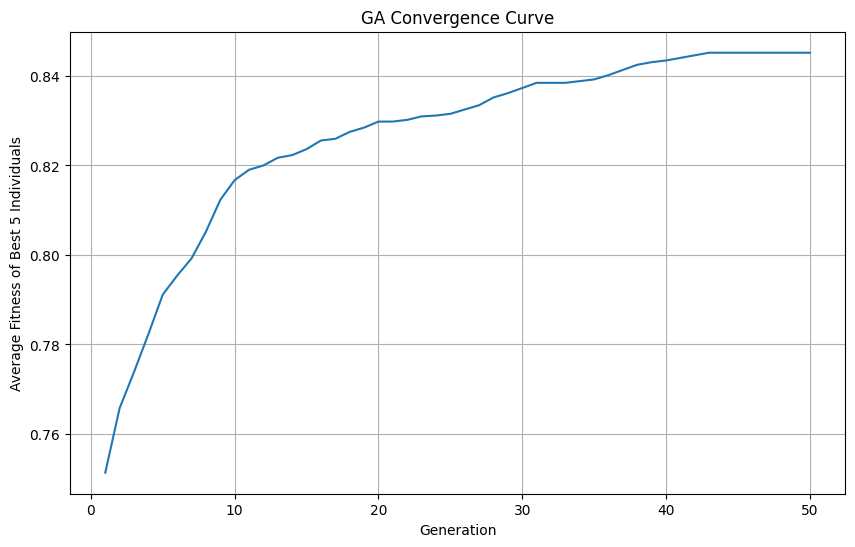

In [11]:
# Plotting the convergence curve for the average fitness of best 5 individuals across generations
import matplotlib.pyplot as plt

# Plot convergence curve
plt.figure(figsize=(10, 6))

plt.plot(x_list, y_list)

plt.xlabel("Generation")
plt.ylabel("Average Fitness of Best 5 Individuals")
plt.title("GA Convergence Curve")

plt.grid(True)
plt.show()

In [12]:
wrapper_ga_times

[1.9678685830440372,
 2.038992749992758,
 1.9880426661111414,
 2.0234004999510944,
 1.9683932501357049]